In [1]:
import pandas as pd
import csv
l=[]

# Open the CSV file
with open('potato.csv', newline='') as csvfile:
    # Create a CSV reader object
    reader = csv.reader(csvfile)
    # Iterate over each row in the CSV file
    for row in reader:
        # Process each row as needed
        l.append(row)
l

[['Date', 'price'],
 ['2000-01-01 00:00:00', '70.7'],
 ['2000-02-01 00:00:00', '58.6'],
 ['2000-03-01 00:00:00', '67.0'],
 ['2000-04-01 00:00:00', '68.7'],
 ['2000-05-01 00:00:00', '77.8'],
 ['2000-06-01 00:00:00', '99.1'],
 ['2000-07-01 00:00:00', '102.6'],
 ['2000-08-01 00:00:00', '98.8'],
 ['2000-09-01 00:00:00', '88.4'],
 ['2000-10-01 00:00:00', '82.6'],
 ['2000-11-01 00:00:00', '82.6'],
 ['2000-12-01 00:00:00', '75.1'],
 ['2001-01-01 00:00:00', '68.2'],
 ['2001-02-01 00:00:00', '77.2'],
 ['2001-03-01 00:00:00', '93.9'],
 ['2001-04-01 00:00:00', '144.3'],
 ['2001-05-01 00:00:00', '197.0'],
 ['2001-06-01 00:00:00', '202.9'],
 ['2001-07-01 00:00:00', '203.0'],
 ['2001-08-01 00:00:00', '203.4'],
 ['2001-09-01 00:00:00', '203.9'],
 ['2001-10-01 00:00:00', '235.4'],
 ['2001-11-01 00:00:00', '260.3'],
 ['2001-12-01 00:00:00', '229.2'],
 ['2002-01-01 00:00:00', '182.7'],
 ['2002-02-01 00:00:00', '151.4'],
 ['2002-03-01 00:00:00', '167.9'],
 ['2002-04-01 00:00:00', '175.1'],
 ['2002-05-01 

In [7]:
import optuna
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.stattools import kpss

In [8]:
df=pd.read_csv('potato.csv')

In [10]:
import pandas as pd
from scipy.stats import mstats
def winsorize_outliers(series, lower_percentile=0.05, upper_percentile=0.95):
    lower_limit = series.quantile(lower_percentile)
    upper_limit = series.quantile(upper_percentile)
    winsorized_values = mstats.winsorize(series, limits=(lower_percentile, 1 - upper_percentile))  # Correcting the upper percentile value
    return winsorized_values

In [11]:
df=pd.read_csv("potato.csv")
scaler = MinMaxScaler(feature_range=(0, 1))
df['price'] = scaler.fit_transform(df['price'].values.reshape(-1,1))
df['price1'] = winsorize_outliers(df['price'], lower_percentile=0.05, upper_percentile=0.95)
df.pop('price')
df['price']=df.pop('price1')
shift=2
for i in range(shift,0,-1):
    df['target-'+str(i)] = df['price'].shift(i)
d=df[shift:]

def windowed_df_to_date_X_y(windowed_dataframe):
    df_as_np = windowed_dataframe.to_numpy()
    dates = df_as_np[:, 0]
    middle_matrix = df_as_np[:, 2:]
    X = middle_matrix.reshape((len(dates), middle_matrix.shape[1], 1))
    Y = df_as_np[:, 1:2]
    return dates, X.astype(np.float32), Y.astype(np.float32)

dates, X, y = windowed_df_to_date_X_y(d)
dates.shape, X.shape, y.shape

q_80 = int(len(dates) * .8)
q_90 = int(len(dates) * .9)
dates_train, X_train, y_train = dates[:q_80], X[:q_80], y[:q_80]
dates_val, X_val, y_val = dates[q_80:q_90], X[q_80:q_90], y[q_80:q_90]
dates_test, X_test, y_test = dates[q_90:], X[q_90:], y[q_90:]

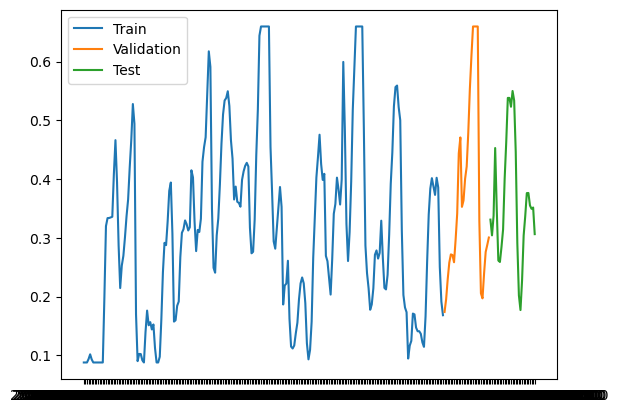

In [12]:
plt.plot(dates_train, y_train)
plt.plot(dates_val, y_val)
plt.plot(dates_test, y_test)

plt.legend(['Train', 'Validation', 'Test'])

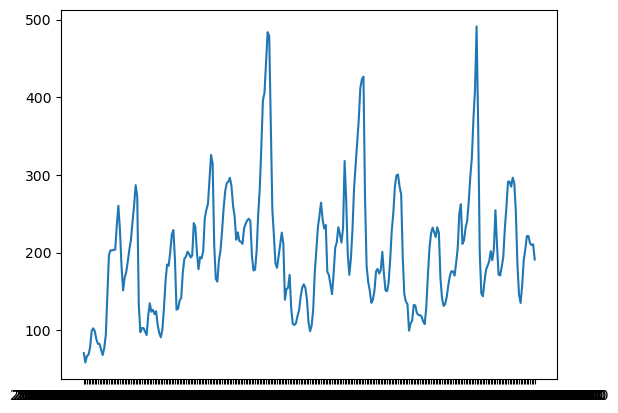

In [14]:
import matplotlib.pyplot as plt
df=pd.read_csv('potato.csv')
plt.plot(df['Date'],df['price'])


In [ ]:
import csv

csv_file = 'data.csv'

with open(csv_file, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerows(f)

print("Data has been saved to", csv_file)
